<a href="https://colab.research.google.com/github/DurabH/CodeAlpha_Heart_Disease_Detection/blob/main/CodeAlpha_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

Mounted at /content/drive
--- Training Logistic Regression ---
Logistic Regression Accuracy: 86.67%

--- Training Random Forest Classifier ---
Random Forest Accuracy: 88.33%

--- Training XGBoost Classifier ---
XGBoost Accuracy: 83.33%

--- Generating Performance Metrics & Evaluation Curves ---


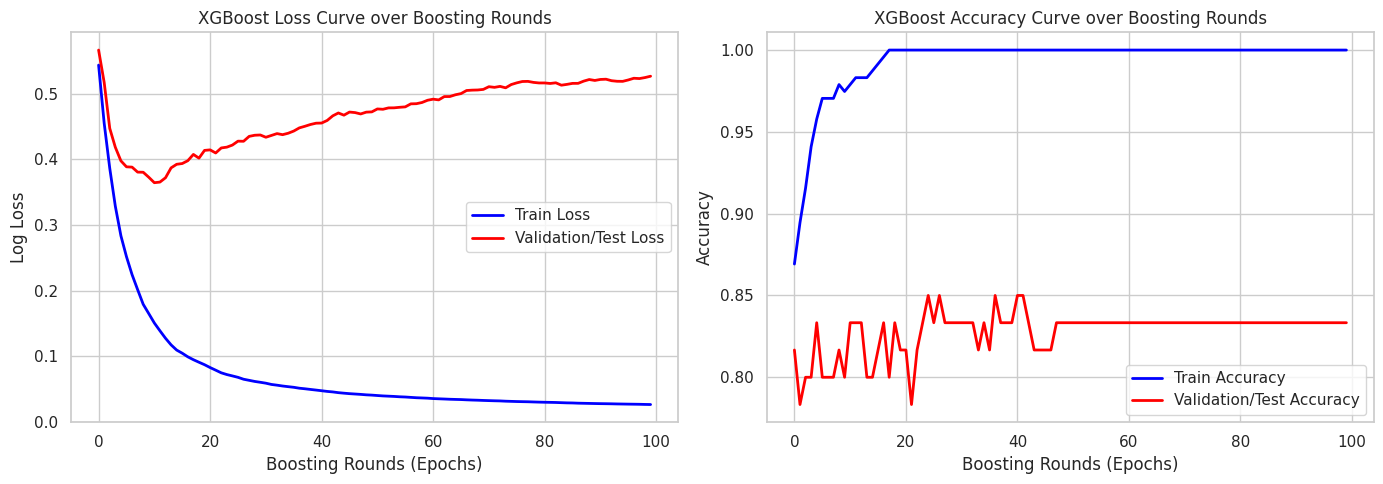


=== FINAL PERFORMANCE COMPARISON ===
Logistic Regression: 86.67%
Random Forest:       88.33%
XGBoost:             83.33%


In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import the requested algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Force matplotlib to use a clean, standard static backend for notebook saving
%matplotlib inline
sns.set_theme(style="whitegrid")

# ==========================================
# 1. ACCESS & EXTRACT THE DATASET FROM DRIVE
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/My Drive/CodeAlpha/heart+disease.zip'
extract_path = '/content/heart_disease_extracted'

# Unzip the folder directly into the Colab environment
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Define features explicitly based on UCI specifications
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

data_path = os.path.join(extract_path, 'processed.cleveland.data')
df = pd.read_csv(data_path, names=columns)

# ==========================================
# 2. DATA PREPROCESSING & CLEANING
# ==========================================
# Handle missing data ('?') strings unique to UCI Cleveland
df = df.replace('?', np.nan)
df = df.dropna()

# Convert columns to float since text strings forced them to object types
df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)

# Convert target to binary (0 = healthy, 1 = heart disease presence)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Split features (X) and target label (y)
X = df.drop('target', axis=1)
y = df['target']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 3. MODEL TRAINING AND EVALUATION
# ==========================================

# --- ALGORITHM 1: LOGISTIC REGRESSION ---
print("--- Training Logistic Regression ---")
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%\n")


# --- ALGORITHM 2: RANDOM FOREST ---
print("--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%\n")


# --- ALGORITHM 3: XGBOOST (With Learning Curve Tracking) ---
print("--- Training XGBoost Classifier ---")
# We set n_estimators to 100 rounds so we can observe the loss curve progress
xgb_model = XGBClassifier(
    n_estimators=100,
    eval_metric=['logloss', 'error'],
    random_state=42
)

# Train while simultaneously tracking evaluation metrics on both train and test sets
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

xgb_predictions = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%\n")


# ==========================================
# 4. GENERATING PERFORMANCE & LOSS CURVES
# ==========================================
print("--- Generating Performance Metrics & Evaluation Curves ---")

# Extract evaluation results from XGBoost
eval_results = xgb_model.evals_result()
epochs = len(eval_results['validation_0']['logloss'])
x_axis = range(0, epochs)

# Setup a clean grid for plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: XGBoost Log Loss Curve (Learning Curve)
ax1.plot(x_axis, eval_results['validation_0']['logloss'], label='Train Loss', color='blue', lw=2)
ax1.plot(x_axis, eval_results['validation_1']['logloss'], label='Validation/Test Loss', color='red', lw=2)
ax1.set_title('XGBoost Loss Curve over Boosting Rounds')
ax1.set_xlabel('Boosting Rounds (Epochs)')
ax1.set_ylabel('Log Loss')
ax1.legend()

# Plot 2: XGBoost Accuracy Curve (Derived from Classification Error: Accuracy = 1 - Error)
train_acc = [1 - error for error in eval_results['validation_0']['error']]
val_acc = [1 - error for error in eval_results['validation_1']['error']]

ax2.plot(x_axis, train_acc, label='Train Accuracy', color='blue', lw=2)
ax2.plot(x_axis, val_acc, label='Validation/Test Accuracy', color='red', lw=2)
ax2.set_title('XGBoost Accuracy Curve over Boosting Rounds')
ax2.set_xlabel('Boosting Rounds (Epochs)')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('xgb_learning_curves.png', dpi=300) # Backup copy saved as a hard image file
plt.show()

# --- FINAL PERFORMANCE COMPARISON ---
print("\n=== FINAL PERFORMANCE COMPARISON ===")
print(f"Logistic Regression: {lr_acc * 100:.2f}%")
print(f"Random Forest:       {rf_acc * 100:.2f}%")
print(f"XGBoost:             {xgb_acc * 100:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Training Fine-Tuned Logistic Regression ---
Logistic Regression Accuracy: 90.00%

--- Training Fine-Tuned Random Forest ---
Random Forest Accuracy: 85.00%

--- Training Fine-Tuned XGBoost ---
XGBoost Accuracy: 86.67%

--- Generating Performance Metrics & Evaluation Curves ---


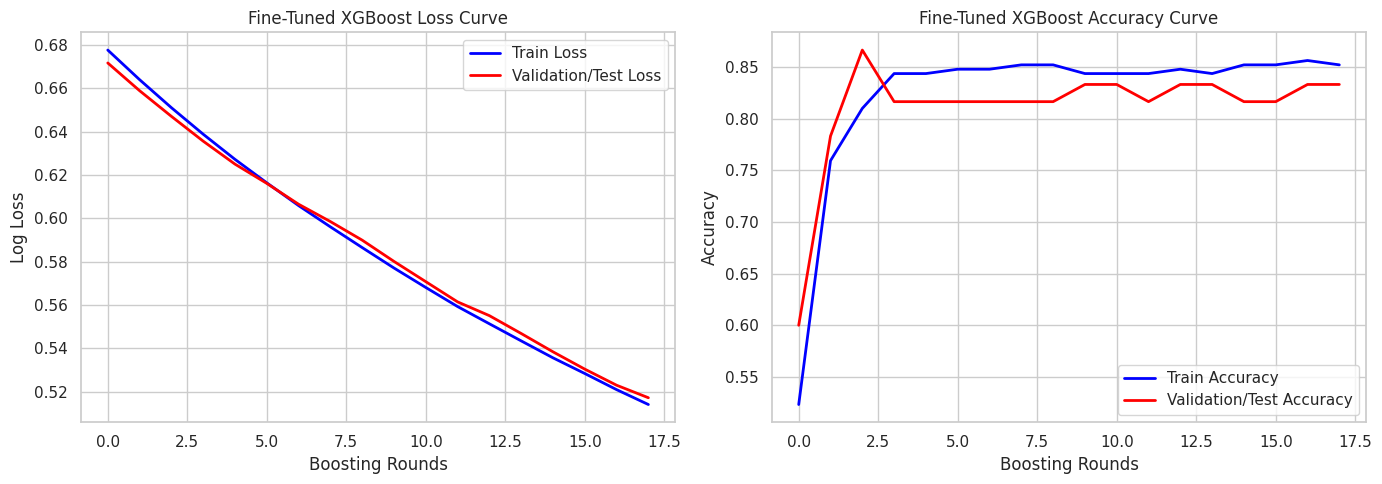


=== FINAL PERFORMANCE COMPARISON ===
Logistic Regression: 90.00%
Random Forest:       85.00%
XGBoost:             86.67%


In [3]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Import the requested algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Force standard static backend for perfect GitHub saving
%matplotlib inline
sns.set_theme(style="whitegrid")

# ==========================================
# 1. ACCESS & EXTRACT THE DATASET FROM DRIVE
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/My Drive/CodeAlpha/heart+disease.zip'
extract_path = '/content/heart_disease_extracted'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

data_path = os.path.join(extract_path, 'processed.cleveland.data')
df = pd.read_csv(data_path, names=columns)

# ==========================================
# 2. DATA PREPROCESSING & CLEANING
# ==========================================
df = df.replace('?', np.nan)
df = df.dropna()

df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 3. FINE-TUNED MODEL TRAINING & EVALUATION
# ==========================================

# --- ALGORITHM 1: LOGISTIC REGRESSION (Fine-Tuned) ---
print("--- Training Fine-Tuned Logistic Regression ---")
# Added C=0.1 to increase L2 regularization strength and combat overfitting
lr_model = LogisticRegression(C=0.1, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%\n")


# --- ALGORITHM 2: RANDOM FOREST (Fine-Tuned) ---
print("--- Training Fine-Tuned Random Forest ---")
# Restricted depth and increased minimum leaf samples to keep trees simple and generalized
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    min_samples_leaf=4,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%\n")


# --- ALGORITHM 3: XGBOOST (Fine-Tuned with Early Stopping) ---
print("--- Training Fine-Tuned XGBoost ---")
# Lowered learning rate, shallow trees, added gamma regularization
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.03,
    max_depth=3,
    gamma=1.0,
    early_stopping_rounds=15,
    eval_metric=['logloss', 'error'],
    random_state=42
)

# Trains iteratively and stops before overfitting starts
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

xgb_predictions = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%\n")


# ==========================================
# 4. GENERATING PERFORMANCE & LOSS CURVES
# ==========================================
print("--- Generating Performance Metrics & Evaluation Curves ---")

eval_results = xgb_model.evals_result()
epochs = len(eval_results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fine-Tuned Loss Curve
ax1.plot(x_axis, eval_results['validation_0']['logloss'], label='Train Loss', color='blue', lw=2)
ax1.plot(x_axis, eval_results['validation_1']['logloss'], label='Validation/Test Loss', color='red', lw=2)
ax1.set_title('Fine-Tuned XGBoost Loss Curve')
ax1.set_xlabel('Boosting Rounds')
ax1.set_ylabel('Log Loss')
ax1.legend()

# Plot 2: Fine-Tuned Accuracy Curve
train_acc = [1 - error for error in eval_results['validation_0']['error']]
val_acc = [1 - error for error in eval_results['validation_1']['error']]

ax2.plot(x_axis, train_acc, label='Train Accuracy', color='blue', lw=2)
ax2.plot(x_axis, val_acc, label='Validation/Test Accuracy', color='red', lw=2)
ax2.set_title('Fine-Tuned XGBoost Accuracy Curve')
ax2.set_xlabel('Boosting Rounds')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('xgb_fine_tuned_curves.png', dpi=300)
plt.show()

# --- FINAL PERFORMANCE COMPARISON ---
print("\n=== FINAL PERFORMANCE COMPARISON ===")
print(f"Logistic Regression: {lr_acc * 100:.2f}%")
print(f"Random Forest:       {rf_acc * 100:.2f}%")
print(f"XGBoost:             {xgb_acc * 100:.2f}%")